# Assignment 1 - Understanding Generative and Discriminative Models Using MNIST

**Name:** Prakruthi BR

**Course:** BCA (AIML)

**REG NO:** 2411021240038

**SUBJECT:** Genarative AI

**Objective:** To understand the basic difference between a discriminative model and a generative model by working with MNIST digits 0 and 1.

For the discriminative part I used Logistic Regression to classify a digit as 0 or 1. For the generative part I used a simple Autoencoder to learn what the digits actually look like, and then used it to reconstruct digits and also create brand new ones.

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)

## Preparing the dataset

MNIST has all 10 digits (0-9), but I only need 0 and 1 for this assignment, so I filtered out the rest. I also normalized the pixel values from the 0-255 range down to 0-1, since that makes training the models faster and more stable.


In [2]:
# loading the full MNIST dataset first
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# keeping only the images where the label is 0 or 1
train_filter = (y_train == 0) | (y_train == 1)
test_filter = (y_test == 0) | (y_test == 1)

x_train = x_train[train_filter]
y_train = y_train[train_filter]

x_test = x_test[test_filter]
y_test = y_test[test_filter]

# scaling pixel values down to the 0-1 range
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Number of training images:", x_train.shape[0])
print("Number of testing images:", x_test.shape[0])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of training images: 12665
Number of testing images: 2115


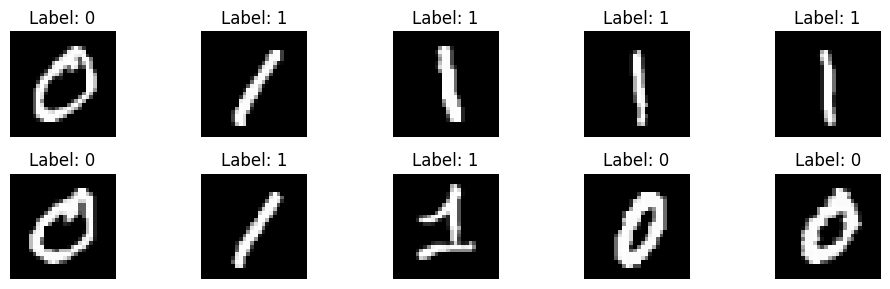

In [3]:
# just looking at a few images to make sure only 0s and 1s are present
plt.figure(figsize=(10, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Label: " + str(y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

## Discriminative Model - Logistic Regression

This model's whole job is to look at an image and decide if it's a 0 or a 1. It doesn't need to know what a 0 or 1 fully looks like, it just needs to find a boundary that separates the two.

Since Logistic Regression expects a flat list of numbers and not a 2D image, I first flattened every 28x28 image into a single row of 784 values.

In [4]:
# flattening the images so they can be given to logistic regression
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

print("Training data shape after flattening:", x_train_flat.shape)
print("Testing data shape after flattening:", x_test_flat.shape)

Training data shape after flattening: (12665, 784)
Testing data shape after flattening: (2115, 784)


In [5]:
# training the logistic regression model
classifier = LogisticRegression(max_iter=1000)
classifier.fit(x_train_flat, y_train)

# getting predictions on the test set
y_pred = classifier.predict(x_test_flat)

# checking how accurate the model is
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of the discriminative model:", round(accuracy * 100, 2), "%")

Accuracy of the discriminative model: 99.95 %


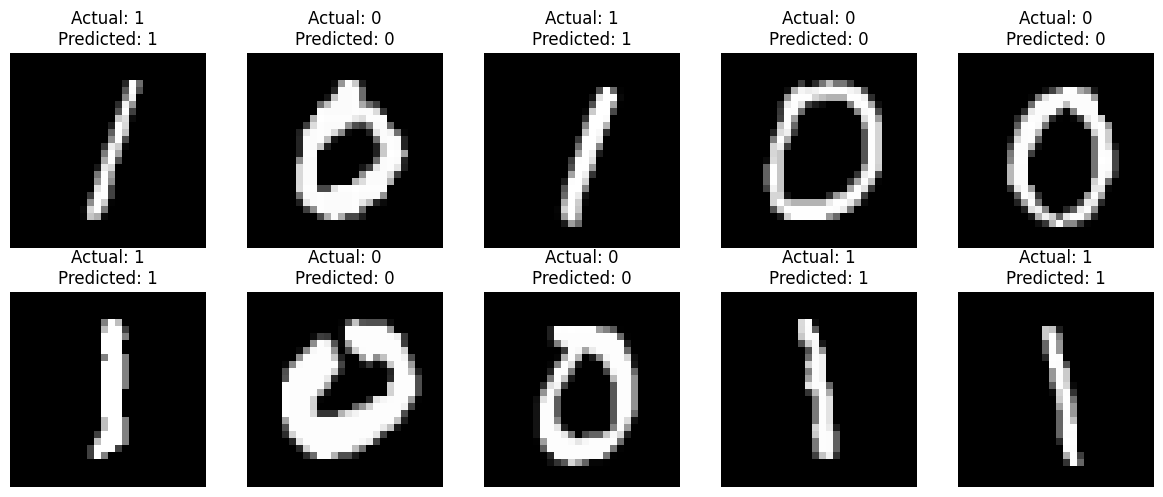

In [6]:
# comparing actual labels with what the model predicted, for a few test images
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Actual: " + str(y_test[i]) + "\nPredicted: " + str(y_pred[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()


## Generative Model - Autoencoder

Unlike the logistic regression model, an autoencoder isn't trying to classify anything. It's trying to learn what the digit images actually look like, in enough detail that it can rebuild them on its own.

It has two parts:
- **Encoder** - squeezes the image down into a much smaller set of numbers
- **Decoder** - takes those numbers and tries to build the image back up from them

If it learns this well enough, I can even feed the decoder some made-up numbers instead of real encoded ones and get a brand new digit image out of it, one that never actually existed in the dataset.

In [7]:
# flattening the images again for the autoencoder, since I'm using Dense layers here too
x_train_auto = x_train.reshape((len(x_train), 784))
x_test_auto = x_test.reshape((len(x_test), 784))


In [8]:
# how many numbers the image gets compressed down to
encoding_dim = 32

input_img = Input(shape=(784,))

# encoder part - compressing step by step
encoded = Dense(128, activation="relu")(input_img)
encoded = Dense(encoding_dim, activation="relu")(encoded)

# decoder part - expanding back to the original size
decoded = Dense(128, activation="relu")(encoded)
decoded = Dense(784, activation="sigmoid")(decoded)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# training the autoencoder to recreate its own input
history = autoencoder.fit(
    x_train_auto, x_train_auto,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_auto, x_test_auto)
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.3330 - val_loss: 0.1787
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1592 - val_loss: 0.1395
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1315 - val_loss: 0.1218
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1185 - val_loss: 0.1121
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1100 - val_loss: 0.1042
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.1026 - val_loss: 0.0980
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0977 - val_loss: 0.0940
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0942 - val_loss: 0.0914
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0913 - val_loss: 0.0885
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0886 - val_loss: 0.0859


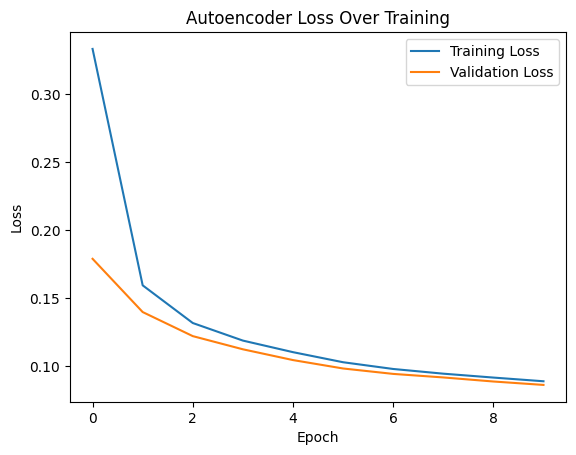

In [10]:
# plotting the loss to check that the model actually improved over the epochs
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Loss Over Training")
plt.legend()
plt.show()

### Reconstructing real digit images

Here I'm passing real test images through the trained autoencoder and looking at how close the output is to the original. This tells me how well it learned the patterns, but these aren't new images, just recreations of existing ones.

In [11]:
reconstructed_images = autoencoder.predict(x_test_auto)

67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


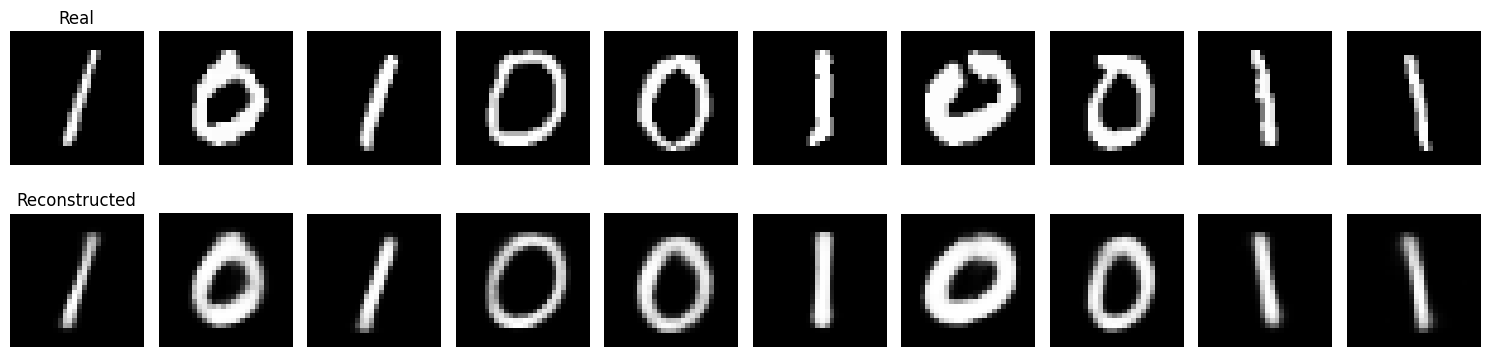

In [12]:
n = 10

plt.figure(figsize=(15, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_auto[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Real")

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Reconstructed")

plt.tight_layout()
plt.show()

### Creating brand new digit images

To actually generate something new (not just recreate an existing digit), I need to give the decoder some encoded numbers that didn't come from a real image. So I first found out what range of values the encoder normally produces for real digits, by checking the mean and standard deviation. Then I picked random numbers from that same range and passed them through just the decoder part.

In [13]:
# building a small model that only does the encoding step
encoder_only = Model(input_img, encoded)

# building a small model that only does the decoding step, reusing the trained decoder layers
decoder_input = Input(shape=(encoding_dim,))
decoder_layer_1 = autoencoder.layers[-2]
decoder_layer_2 = autoencoder.layers[-1]
decoder_output = decoder_layer_2(decoder_layer_1(decoder_input))
decoder_only = Model(decoder_input, decoder_output)

396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


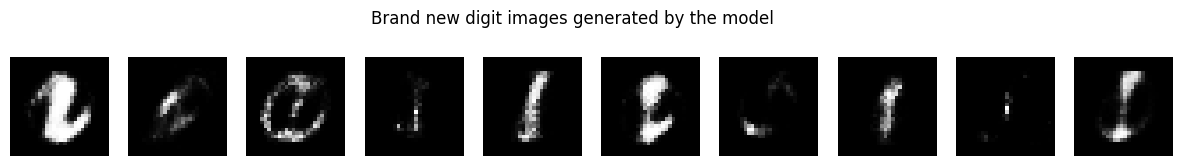

In [14]:
# checking the typical range of encoded values for real training images
encoded_train = encoder_only.predict(x_train_auto)
encoded_mean = encoded_train.mean(axis=0)
encoded_std = encoded_train.std(axis=0)

# picking random values in that same range, these don't come from any real image
n_new = 10
random_codes = np.random.normal(loc=encoded_mean, scale=encoded_std, size=(n_new, encoding_dim))

# decoding the random values into new digit images
new_images = decoder_only.predict(random_codes)

plt.figure(figsize=(15, 2))
for i in range(n_new):
    plt.subplot(1, n_new, i + 1)
    plt.imshow(new_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Brand new digit images generated by the model")
plt.show()

## Putting everything together for comparison

Here I am lining up the real digit, what the discriminative model predicted for it, what the autoencoder reconstructed from it, and a completely new image the autoencoder made up on its own.

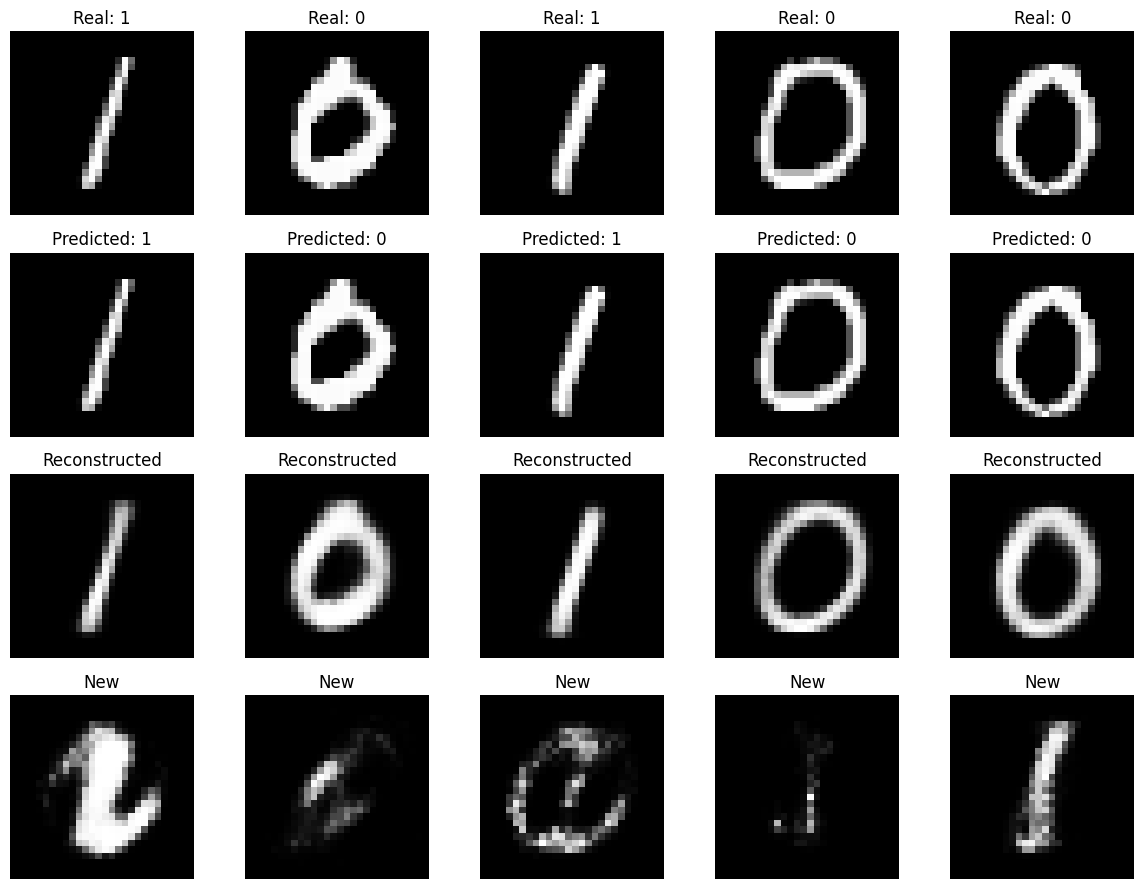

Discriminative model accuracy: 99.95 %


In [16]:
n = 5

plt.figure(figsize=(12, 9))

for i in range(n):
    plt.subplot(4, n, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Real: " + str(y_test[i]))
    plt.axis("off")

    plt.subplot(4, n, i + 1 + n)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Predicted: " + str(y_pred[i]))
    plt.axis("off")

    plt.subplot(4, n, i + 1 + (2 * n))
    plt.imshow(reconstructed_images[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

    plt.subplot(4, n, i + 1 + (3 * n))
    plt.imshow(new_images[i].reshape(28, 28), cmap="gray")
    plt.title("New")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Discriminative model accuracy:", round(accuracy * 100, 2), "%")

## Written Reflection

**What did the discriminative model learn?**

The logistic regression model learned where the boundary is between digit 0 and digit 1 in terms of pixel values. It doesn't understand what a 0 or a 1 fully looks like as a whole, it just picked up on which pixels tend to differ between the two and used that to separate them. It reached a good accuracy, but its only job is telling the two apart, it can't create a digit image on its own.

**What did the generative model learn?**

The autoencoder learned the actual patterns and structure that make up a 0 or a 1, like the shape of the loop or the straight line. Because it learned this, it could take a real image and rebuild it closely, and it could also take made-up numbers that were never tied to any real image and still produce something that looks like a genuine handwritten digit.

**How are the two approaches different?**

The discriminative model only cares about separating the classes, so it throws away a lot of detail about what the digit actually looks like since it doesn't need that to classify. The generative model instead tries to understand the full picture of what the data looks like, which is exactly why it is able to generate new digits while the discriminative model cannot. In short, one model learns a boundary between classes, and the other learns the data itself.

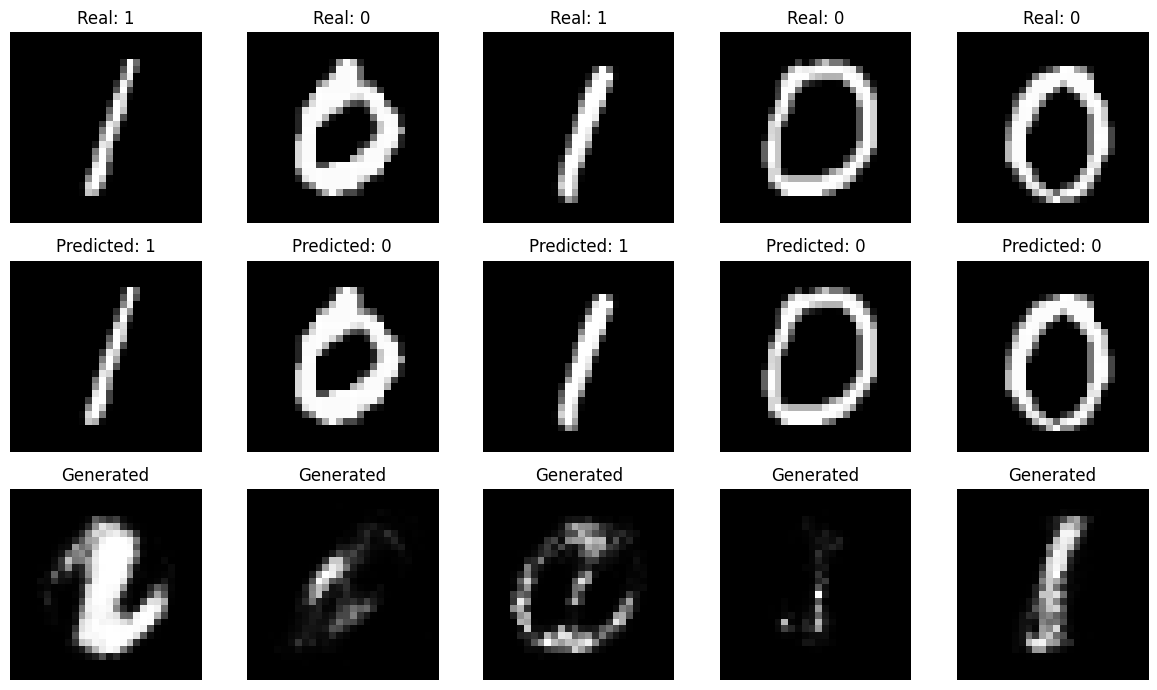

Discriminative model accuracy: 99.95 %


In [17]:
n = 5

plt.figure(figsize=(12, 7))

for i in range(n):
    # Real image
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Real: " + str(y_test[i]))
    plt.axis("off")

    # Prediction from the discriminative model
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Predicted: " + str(y_pred[i]))
    plt.axis("off")

    # Newly generated image from the generative model
    plt.subplot(3, n, i + 1 + (2 * n))
    plt.imshow(new_images[i].reshape(28, 28), cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Discriminative model accuracy:", round(accuracy * 100, 2), "%")